# Single-cell Analysis of ENKTCL Immune Microenvironment Dynamics (Figure 1)

**Manuscript Context:** This notebook contains the code and workflows used to generate **Figure 1b–d** and **Table S2** for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to characterize the cellular landscape of ENKTCL patients treated with PD-1-based chemoimmunotherapy. Specifically, we:
1.  Visualize the global cellular architecture using UMAP.
2.  Validate cell type identities using canonical markers.
3.  Quantify the compositional changes in the tumor microenvironment before and after immune checkpoint inhibitor (ICI) treatment.

In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import numpy as np
import os
import seaborn as sns
import sys
print(sys.version)

3.11.11 (main, Dec 11 2024, 16:28:39) [GCC 11.2.0]


In [687]:
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter, PercentFormatter
figPath = "./figures/fig1"
datPath = "./data/NKTCL_concat.h5ad"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14

In [ ]:
adata_concat = sc.read_h5ad(datPath)
adata_concat.var_names = list(adata_concat.var_names)
adata_concat.var_names_make_unique()

### Evaluate the impact of P-GemOx + ICI chemotherapy on the quality of scRNA-seq data

In [702]:
import numpy as np
from scipy.stats import mannwhitneyu
from collections import Counter

# Count the number of cells per sample (batch)
cell_counts = Counter(adata_concat.obs['batch'])

# Group samples by treatment status
# pre_treatment: samples ending with "_0" (before treatment)
# post_treatment: samples ending with "_1" (after treatment)
pre_treatment = np.array([v for k, v in cell_counts.items() if k.endswith('_0')])
post_treatment = np.array([v for k, v in cell_counts.items() if k.endswith('_1')])

# Perform Mann-Whitney U test (non-parametric test)
# Two-sided test: compare distribution differences between two groups
# Exact method: recommended for small sample sizes
# Continuity correction: improve accuracy for small datasets
stat, p_value = mannwhitneyu(
    x=pre_treatment, 
    y=post_treatment, 
    alternative='two-sided',
    use_continuity=True,
    method='exact'
)

# Output statistical results
print(f"U statistic: {stat}")
print(f"P-value: {p_value:.4f}")

# Interpret the result
alpha = 0.05
if p_value > alpha:
    print(f"Not significant (p > {alpha}): No significant difference in cell counts between pre- and post-treatment samples → scRNA-seq quality is reliable ✅")
else:
    print(f"Significant (p < {alpha}): Cell counts differ significantly between groups → caution needed for downstream analysis ❌")

U statistic: 33.0
P-value: 1.0000
Not significant (p > 0.05): No significant difference in cell counts between pre- and post-treatment samples → scRNA-seq quality is reliable ✅


#### **Supplementary Table 2.** Overall quality metrics and cell composition of single-cell samples from patients with ENKTCL.

In [703]:
# ---------------------------------------------------------
# Calculate and export batch-wise quality control statistics
# ---------------------------------------------------------
# This section computes the median values for key QC metrics 
# (number of genes, mitochondrial percentage, and total counts) 
# grouped by batch to assess technical consistency. 
# The results are saved to a CSV file for Table S2.
# ---------------------------------------------------------
batch_median = adata_concat.obs[['batch', 'n_genes_by_counts', 'mt_frac', 'total_counts']].groupby('batch').median()
batch_median.columns = [
    'Median genes per cell',
    'Median MT%',
    'Median counts per cell'
]
print("Median statistics per batch:")
print(batch_median)
batch_median.to_csv(f"{figPath}/Tab2.batch_statistics.csv")

Median statistics per batch:
        Median genes per cell  Median MT%  Median counts per cell
batch                                                            
NK10_0                 1889.0    0.011635                  4438.0
NK11_0                 2369.0    0.020987                  5846.0
NK11_1                 1026.0    0.007803                  2452.0
NK1_0                  2468.0    0.014535                  5353.0
NK2_0                  1352.0    0.021750                  2807.0
NK3_0                  1545.0    0.019802                  3465.5
NK4_0                  1794.0    0.011401                  3838.5
NK5_0                  1897.0    0.007790                  4061.0
NK5_1                  1225.0    0.010702                  2518.0
NK6_0                  2351.5    0.012732                  6019.0
NK6_1                  1749.5    0.015194                  3847.0
NK7_0                  1774.0    0.017444                  3633.0
NK7_1                  1498.0    0.011487      

/tmp/ipykernel_3335451/3753250524.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_median = adata_concat.obs[['batch', 'n_genes_by_counts', 'mt_frac', 'total_counts']].groupby('batch').median()


In [704]:
# ---------------------------------------------------------
# Calculate and export cell type proportions per batch
# ---------------------------------------------------------
# This section calculates the percentage of each cell type 
# (anno-pca) within each batch. It normalizes the counts 
# to the total number of cells per batch to determine 
# relative abundance. The resulting pivot table is saved 
# to a CSV file, for use in Figure 1d or Table S2.
# ---------------------------------------------------------
df = adata_concat.obs[['batch', 'anno-pca']].copy()
batch_count = df.groupby(['batch', 'anno-pca']).size().reset_index(name='count')
batch_total = batch_count.groupby('batch')['count'].transform('sum')
batch_count['proportion (%)'] = (batch_count['count'] / batch_total * 100).round(2)
result = batch_count.pivot(index='anno-pca', columns='batch', values='proportion (%)').fillna(0).T
result.to_csv(f"{figPath}/Tab2.batch_anno-proportion.csv")

/tmp/ipykernel_3335451/929164781.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_count = df.groupby(['batch', 'anno-pca']).size().reset_index(name='count')
/tmp/ipykernel_3335451/929164781.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_total = batch_count.groupby('batch')['count'].transform('sum')


#### **Fig. 1b** Uniform manifold approximation and projection (UMAP) visualization of single-cell RNA sequencing data from ENKTCL samples. The cells are colored according to their assigned cell type, revealing distinct clusters of myeloid, B, endothelial, NK, immune mixed, mast, T, stromal, and epithelial cells.

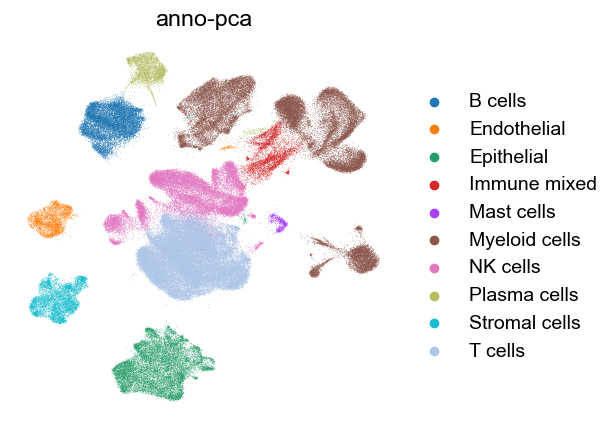

In [701]:
fig, ax = plt.subplots(figsize=(5,5))
sc.pl.umap(adata_concat, color=['anno-pca'], ax=ax, show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f'{figPath}/Fig1b.png', dpi=400, bbox_inches='tight')

#### **Fig. 1c** Dot plot showing the expression of canonical markers across different cell types identified in the ENKTCL samples. The size of the dots represents the fraction of cells expressing the gene, and the color intensity indicates the mean expression level.

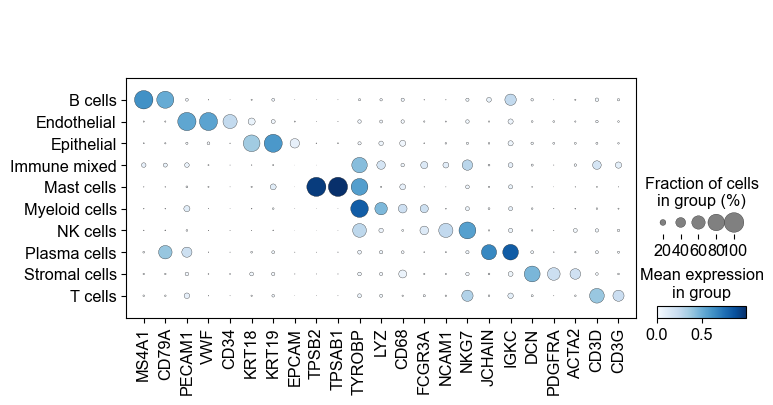

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
sc.pl.dotplot(adata_concat, var_names=[
  'MS4A1', 'CD79A', 
  'PECAM1', 'VWF', 'CD34', 'KRT18', 'KRT19', 'EPCAM',
  'TPSB2', 'TPSAB1', 'TYROBP','LYZ', 'CD68',  'FCGR3A','NCAM1', 'NKG7',
  'JCHAIN','IGKC', 'DCN', 'PDGFRA', 'ACTA2', 'CD3D', 'CD3G',
], groupby='anno-pca',cmap='Blues', ax=ax)
fig.savefig(f"{figPath}/Fig1c.svg", bbox_inches='tight')

#### **Fig. 1d** Stacked bar plot comparing the proportions of different cell types before and after ICI treatment. Each bar represents a cell type, and the height of the bar indicates the percentage of cells within that group.

In [698]:
# ---------------------------------------------------------
# Custom Function: Stacked Bar Plot for Cell Proportions
# ---------------------------------------------------------
# This function visualizes the relative abundance of different 
# cell types (or groups) across samples (e.g., Patients).
# 
# Key Features:
# 1. Normalization: Automatically normalizes raw counts to percentages (0-100%).
# 2. Stacking: Uses cumulative sums to stack bars correctly.
# 3. Formatting: 
#    - Y-axis is formatted as percentages.
#    - Legend is placed outside the plot (bottom) for clarity.
#    - Spines (top/right) are removed for a cleaner look.
# ---------------------------------------------------------
def propPlot(age_df, barlabels, ax, colors=sc.pl.palettes.default_20, xlabel='Patient ID', show_y=True, xrotate=90):
    all_df = age_df.sum(axis=1)
    age_normdf = pd.DataFrame([age_df.loc[i,:]/all_df[i] for i in barlabels], index=barlabels)
    age_cumdf = pd.DataFrame([np.cumsum(age_normdf.loc[i,:]) for i in barlabels], index=barlabels)
    norm_gdfs = age_normdf
    cum_gdfs = age_cumdf
    for i, col in enumerate(age_df.columns):
        height = norm_gdfs[col]
        starts = cum_gdfs[col] - height
        rects = ax.bar(barlabels, height, bottom=starts, width=0.9, color=colors[i], edgecolor='white', linewidth=0.5,
                        label=col, alpha=1)
    
        # ax.bar_label(rects,age_df.loc[:, col], label_type='center', color='lightgrey', fontsize=14)
    ax.legend( bbox_to_anchor=(1, -0.3), 
              handletextpad=0.5, frameon=False,
                          borderpad=0.4,
                          columnspacing=1,
                          handlelength=0.65,
              loc='lower left')
    if show_y:
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1,decimals=0))
        ax.set_ylabel('Cell proportions')
    else:
        ax.yaxis.set_visible(False)
        ax.spines.left.set_visible(False)
    ax.set_xlabel(xlabel)
    ax.set_xticks(barlabels)
    ax.set_xticklabels(labels=barlabels,rotation=xrotate)
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

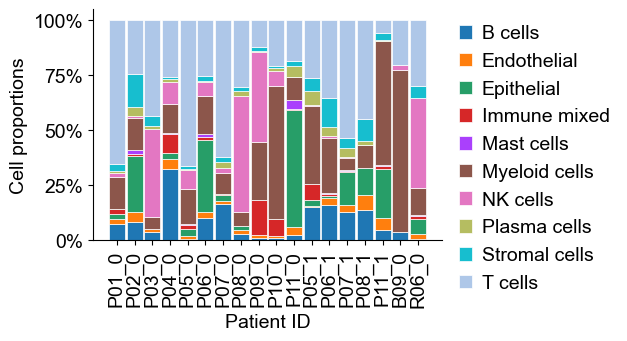

In [ ]:
# -----------------------------------------------------------------------------
# Data Preparation & Plotting: NK Cell Proportions across Patients
# -----------------------------------------------------------------------------
# 1. Define specific sample batches (barlabels) to visualize.
# 2. Extract unique cell types from the 'anno-pca' annotation.
# 3. Construct 'age_df': A DataFrame where rows are samples and columns are cell types,
#    containing the raw counts of cells for each combination.
#
# Note on Labeling:
# To clearly distinguish patient samples from NK cell cluster IDs (e.g., NK1_0),
# we format the X-axis labels with a 'P' prefix (e.g., P01_0) in the final plot.
# -----------------------------------------------------------------------------
barlabels = [ 'NK1_0', 'NK2_0', 'NK3_0', 'NK4_0','NK5_0', 
             'NK6_0','NK7_0',  'NK8_0', 'NK9_0','NK10_0', 
             'NK11_0','NK5_1', 'NK6_1','NK7_1', 'NK8_1',
             'NK11_1', 'PB9_0', 'RR6_0']
cell_types = list(adata_concat.obs['anno-pca'].unique())
cell_types.sort()
age_df = pd.DataFrame(columns = list(cell_types))
for bar in barlabels:
    d1 = pd.DataFrame([len(adata_concat[(adata_concat.obs["anno-pca"] == ct) & (adata_concat.obs["batch"] == bar)]) for ct in list(cell_types)], index = list(cell_types), columns=[bar]).T
    age_df = pd.concat([age_df, d1])
fig0, ax0 = plt.subplots(figsize=(4.5, 3))
propPlot(age_df, ax=ax0, barlabels=barlabels)
ax0.set_xticklabels(['P01_0', 'P02_0', 'P03_0', 'P04_0','P05_0', 
             'P06_0','P07_0',  'P08_0', 'P09_0','P10_0', 
             'P11_0','P05_1', 'P06_1','P07_1', 'P08_1',
             'P11_1', 'B09_0', 'R06_0'])
fig0.savefig(f"{figPath}/Fig1d.svg",bbox_inches='tight')